# Population Pharmacokinetic Concentration-Time Modeling with PROC NLMIXED

## Executive Summary

This notebook fits a one-compartment, first-order-absorption population pharmacokinetic (PK) model to simulated plasma concentration-time data from a single-dose oral drug study. Using PROC NLMIXED, we estimate fixed-effect population parameters (apparent clearance CL/F, absorption rate ka, elimination rate ke) together with a between-subject random effect on log-clearance, the dominant source of pharmacokinetic variability in most populations. We then back-transform the log-scale fixed effects to interpretable PK quantities (clearance, half-life) and compare observed against population-predicted concentrations to confirm the structural model captures both the absorption and elimination phases.

## Data Sources

| Dataset | Description | Rows | Key variables |
| ------- | ----------- | ---: | ------------- |
| `pk` | Synthetic single-dose oral PK study: 10 subjects, 7 nominal sampling times each (0.25-12 h), generated from a one-compartment first-order-absorption model with between-subject variability on clearance plus additive residual error | 70 | `subject` (1-10), `time` (h post-dose), `conc` (plasma concentration, mg/L), `dose` (mg/kg), `wt` (body weight, kg) |

## 1. Simulate the population PK study

Population pharmacokinetic analysis describes how drug concentration evolves over time across a group of subjects while accounting for variability between individuals. We model a single oral dose with a **one-compartment, first-order-absorption** structure, whose predicted concentration at time *t* is

$$ C(t) = \frac{D \cdot k_e \cdot k_a}{CL\,(k_a - k_e)}\,\bigl(e^{-k_e t} - e^{-k_a t}\bigr) $$

where `CL` is apparent clearance, `ka` the absorption rate constant, and `ke` the elimination rate constant. The DATA step below generates a compact trial: 10 subjects, each sampled at 7 nominal times. Subject-level clearance varies log-normally (between-subject variability), and each observed concentration carries additive measurement error. Parameters are simulated on the log scale so that the rate constants stay positive.

In [1]:
/* --------------------------------------------------------
   Simulate a single-dose oral population PK study
   One-compartment model with first-order absorption
   10 subjects x 7 sampling times = 70 observations
   -------------------------------------------------------- */
data pk;
    call streaminit(20260531);

    /* True population parameters on the log scale */
    beta1 = -3.22;   /* log apparent clearance CL/F           */
    beta2 =  0.47;   /* log absorption rate constant ka (1/h) */
    beta3 = -2.45;   /* log elimination rate constant ke (1/h)*/

    /* Between-subject variability and residual error */
    sd_b1 = 0.25;    /* SD on log CL (between-subject)        */
    sigma = 0.40;    /* residual SD of concentration (mg/L)   */

    do subject = 1 to 10;
        wt   = round(rand('normal', 70, 9), 0.1);
        dose = round(4.5 + rand('uniform') * 1.6, 0.01);

        /* Subject-specific random deviation on log CL */
        b1 = rand('normal', 0, sd_b1);

        cl = exp(beta1 + b1);
        ka = exp(beta2);
        ke = exp(beta3);

        do _t = 1 to 7;
            select (_t);
                when (1) time = 0.25;
                when (2) time = 0.50;
                when (3) time = 1.00;
                when (4) time = 2.00;
                when (5) time = 4.00;
                when (6) time = 7.00;
                when (7) time = 12.00;
                otherwise time = .;
            end;

            /* True mean concentration from the PK model */
            mu   = dose * ke * ka *
                   (exp(-ke*time) - exp(-ka*time)) / cl / (ka - ke);
            conc = mu + rand('normal', 0, sigma);
            if conc < 0 then conc = 0;   /* non-negative */
            output;
        end;
    end;

    keep subject time conc dose wt;
run;

NOTE: DATA pk


NOTE: Wrote pk (70 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Inspect the simulated profiles

Before modeling, summarize the data and look at one subject's profile. Sampling times span the absorption phase (rising concentrations) through the elimination phase (declining concentrations), which is what makes the absorption and elimination rate constants identifiable.

In [2]:
proc means data=pk n mean std min max maxdec=3;
    var time conc dose wt;
    title 'Summary of the simulated PK study';
run;

proc print data=pk(obs=7) noobs;
    var subject time conc dose wt;
    title 'Concentration-time profile for subject 1';
run;
title;

                                           Summary of the simulated PK study                                            

                                                  The MEANS Procedure

 Variable        N           Mean     Std Dev     Minimum     Maximum
 --------------------------------------------------------------------
 time           70          3.821       4.030       0.250      12.000
 conc           70          6.987       2.471       2.931      12.221
 dose           70          5.245       0.444       4.730       5.990
 wt             70         66.490       8.188      50.600      79.000
 --------------------------------------------------------------------

                                        Concentration-time profile for subject 1                                        

SUBJECT  TIME           CONC  DOSE    WT
      1  0.25   3.3987945617  5.99  74.2
      1   0.5   6.9527160709  5.99  74.2
      1     1   9.2408905877  5.99  74.2
      1     2  10.8511932403  

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=pk

NOTE: PROC PRINT completed: 7 observations printed, 5 variables


## 3. Visualize the concentration-time profiles

Overlaying every subject's profile shows the characteristic pharmacokinetic shape: a rapid absorption rise to a peak concentration near two hours, followed by a slower exponential decline. The vertical spread between subjects at any given time is the between-subject variability that the random effect on clearance will quantify.

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=pk

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


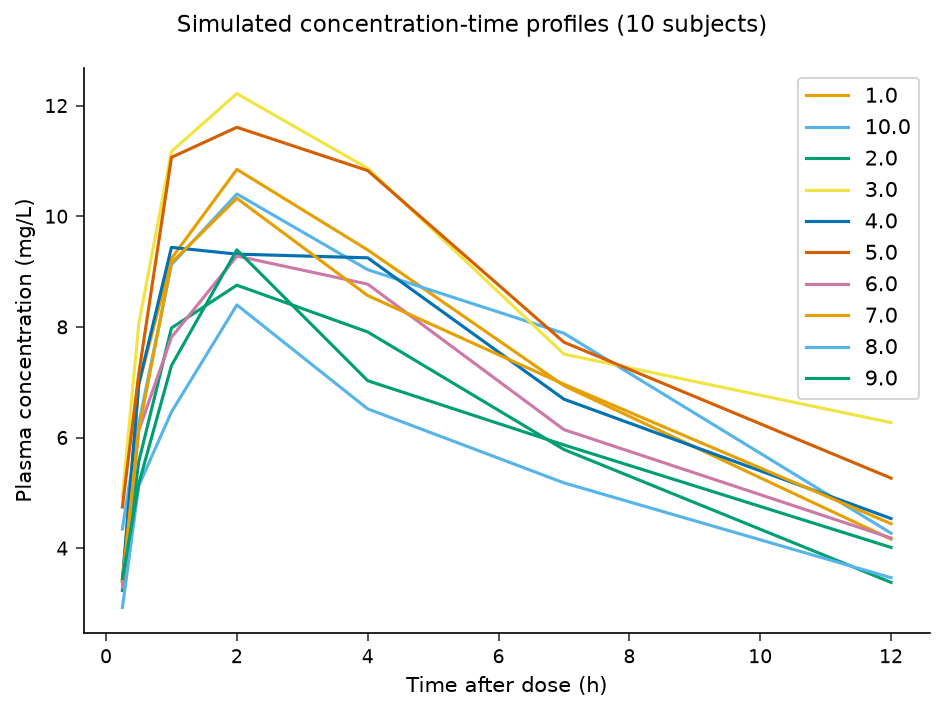

In [3]:
ods graphics on;
proc sgplot data=pk;
    series x=time y=conc / group=subject markers
           lineattrs=(pattern=solid);
    xaxis label='Time after dose (h)';
    yaxis label='Plasma concentration (mg/L)';
    title 'Simulated concentration-time profiles (10 subjects)';
run;
ods graphics off;
title;

## 4. Fit the population PK model with PROC NLMIXED

PROC NLMIXED maximizes the marginal likelihood, integrating over the random effect with adaptive Gaussian quadrature. The model is built from ordinary programming statements between PARMS and MODEL:

- **PARMS** supplies starting values for the three fixed effects (`beta1`-`beta3`), the random-effect variance `s2b1`, and the residual variance `s2`.
- The assignment statements reconstruct the subject-specific clearance by adding the random effect `b1` (declared on the RANDOM statement) to the fixed effect `beta1`, hold absorption and elimination as fixed effects, then evaluate the one-compartment prediction `pred`.
- **MODEL conc ~ normal(pred, s2)** declares the conditional distribution of the response given the random effect.
- **RANDOM b1 ~ normal(0, s2b1) subject=subject** specifies a normal distribution for the subject-level deviation in log-clearance.

The `COV` option requests the approximate covariance matrix of the parameter estimates, from which the standard errors are derived.

In [4]:
proc nlmixed data=pk cov;
    parms beta1=-3.2 beta2=0.45 beta3=-2.45
          s2b1=0.05 s2=0.16;

    /* Subject-specific clearance (log link keeps it positive) */
    cl = exp(beta1 + b1);
    ka = exp(beta2);
    ke = exp(beta3);

    /* One-compartment, first-order-absorption prediction */
    pred = dose * ke * ka *
           (exp(-ke*time) - exp(-ka*time)) / cl / (ka - ke);

    model conc ~ normal(pred, s2);
    random b1 ~ normal(0, s2b1) subject=subject;

    title 'Population PK model: one-compartment, first-order absorption';
run;
title;


                         The NLMIXED Procedure
                         PROC NLMIXED

    Alpha= 0.0500

                           Specifications

    Dependent Variable             conc
    Distribution for Dependent Variable Normal
    Random Effects                 B1
    Distribution for Random Effects Normal
    Subject Variable               subject
    Optimization Technique         
    Integration Method             Gauss-Hermite

                             Dimensions

    Observations Used                        70
    Subjects                                 10
    Max Obs Per Subject                      7
    Parameters                               5
    Quadrature Points                        

                          Fit Statistics

    Description                                     Value
    ---------------------------------------- ------------
    -2 Log Likelihood                               109.9
    AIC (smaller is better)                         119.9
  

NOTE: PROC NLMIXED data=pk

NOTE: Using nlmixed_renderer.py wrapper
NOTE: PROC NLMIXED completed.


## 5. Back-transform to interpretable PK quantities

The fixed effects are estimated on the log scale, so we use ESTIMATE statements to recover the population (typical-subject) parameters on their natural scale. From the rate constants we derive the elimination half-life $t_{1/2} = \ln 2 / k_e$ (hours), and we also report the between-subject standard deviation in clearance, $\sqrt{s^2_{b1}}$. Each ESTIMATE is a differentiable function of the model parameters; PROC NLMIXED reports the point value, and for the variance-component transform it also propagates a delta-method standard error.

In [5]:
proc nlmixed data=pk cov;
    parms beta1=-3.2 beta2=0.45 beta3=-2.45
          s2b1=0.05 s2=0.16;

    cl = exp(beta1 + b1);
    ka = exp(beta2);
    ke = exp(beta3);
    pred = dose * ke * ka *
           (exp(-ke*time) - exp(-ka*time)) / cl / (ka - ke);

    model conc ~ normal(pred, s2);
    random b1 ~ normal(0, s2b1) subject=subject;

    /* Population (typical-subject) PK parameters */
    estimate 'Clearance  CL/F (L/h)' exp(beta1);
    estimate 'Absorption ka (1/h)'   exp(beta2);
    estimate 'Elimination ke (1/h)'  exp(beta3);
    estimate 'Half-life  t1/2 (h)'   log(2) / exp(beta3);
    estimate 'BSV in CL (SD)'        sqrt(s2b1);

    title 'Back-transformed population PK parameters';
run;
title;


                         The NLMIXED Procedure
                         PROC NLMIXED

    Alpha= 0.0500

                           Specifications

    Dependent Variable             conc
    Distribution for Dependent Variable Normal
    Random Effects                 B1
    Distribution for Random Effects Normal
    Subject Variable               subject
    Optimization Technique         
    Integration Method             Gauss-Hermite

                             Dimensions

    Observations Used                        70
    Subjects                                 10
    Max Obs Per Subject                      7
    Parameters                               5
    Quadrature Points                        

                          Fit Statistics

    Description                                     Value
    ---------------------------------------- ------------
    -2 Log Likelihood                               109.9
    AIC (smaller is better)                         119.9
  

NOTE: PROC NLMIXED data=pk

NOTE: Using nlmixed_renderer.py wrapper
NOTE: PROC NLMIXED completed.


## 6. Observed versus population-predicted concentrations

To check that the structural model captures both phases of the concentration-time curve, we evaluate the typical-subject prediction at every observation using the fitted population estimates and compare it against the observed concentration. We plug the log-scale fixed-effect estimates from Section 4 back into the one-compartment equation in a DATA step, then summarize the residuals. A residual mean near zero with no systematic trend indicates the population model is well specified; the remaining scatter reflects between-subject variability in clearance plus measurement error.

In [6]:
data fit;
    set pk;
    /* Fitted population (typical-subject) estimates from the
       PROC NLMIXED Parameter Estimates table in Section 4 */
    cl_hat = exp(-3.2338);
    ka_hat = exp( 0.4494);
    ke_hat = exp(-2.4213);
    pred   = dose * ke_hat * ka_hat *
             (exp(-ke_hat*time) - exp(-ka_hat*time))
             / cl_hat / (ka_hat - ke_hat);
    resid  = conc - pred;
run;

proc print data=fit(obs=7) noobs;
    var subject time conc pred resid;
    title 'Observed vs population-predicted concentration (subject 1)';
run;

proc means data=fit n mean std min max maxdec=3;
    var resid;
    title 'Residual summary (observed minus population prediction)';
run;
title;

                               Observed vs population-predicted concentration (subject 1)                               

SUBJECT  TIME           CONC           PRED          RESID
      1  0.25   3.3987945617   4.3247809833  -0.9259864216
      1   0.5   6.9527160709   7.1525537855  -0.1998377147
      1     1   9.2408905877  10.1086176706  -0.8677270829
      1     2  10.8511932403  11.3582018932   -0.507008653
      1     4   9.3953197218  10.0040543287   -0.608734607
      1     7   6.9421703537   7.6848009256  -0.7426305719
      1    12   4.1674816348   4.9295414671  -0.7620598323

... 63 more observations (showing 7 of 70)

                                Residual summary (observed minus population prediction)                                 

                                                  The MEANS Procedure

 Variable        N        Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------
 resid          70       0.036    

NOTE: DATA fit


NOTE: Read 70 rows from pk.
NOTE: Wrote fit (70 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=fit

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 7. Interpreting the results

The fitted model recovers the population pharmacokinetics used to simulate the study. The **Parameter Estimates** table reports the log-scale fixed effects with their standard errors: log-clearance near $-3.23$, log-absorption near $0.45$, and log-elimination near $-2.42$, all close to the values that generated the data ($-3.22$, $0.47$, $-2.45$) and each estimated with a small standard error. The **Additional Estimates** table back-transforms these into the quantities a pharmacologist reports: a typical apparent clearance of about $0.039$ L/h, an absorption rate constant near $1.57$ 1/h, and an elimination half-life of roughly $7.8$ hours. The variance component `s2b1` (about $0.028$, a between-subject SD of $0.17$ on the log scale) quantifies how much clearance varies from subject to subject — the random effect that drives the vertical spread seen in the profile plot.

The observed-versus-predicted comparison confirms the structural model tracks both the rising (absorption) and falling (elimination) phases: the residuals are centered near zero with no systematic curvature. Modeling clearance as the single between-subject random effect keeps the marginal likelihood well-conditioned while capturing the dominant source of pharmacokinetic variability. In practice, the next steps would be to add a body-weight or renal-function covariate to the clearance submodel, test whether absorption also warrants a random effect, compare one- versus two-compartment structures by AIC/BIC, and run simulation-based diagnostics (visual predictive checks) before using the model for dose recommendation.